In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_tangent_normal(x_func, y_func, t0, dt=1e-5):
    """
    Computes unit tangent and normal vectors for a parametric curve at t0.
    """
    # Numerical derivatives
    dx_dt = (x_func(t0 + dt) - x_func(t0 - dt)) / (2 * dt)
    dy_dt = (y_func(t0 + dt) - y_func(t0 - dt)) / (2 * dt)
    
    # Tangent vector
    tangent = np.array([dx_dt, dy_dt])
    tangent_norm = np.linalg.norm(tangent)
    
    if tangent_norm < 1e-10:
        return None, None, None
    
    tangent_unit = tangent / tangent_norm
    
    # Rotate tangent by +pi/2 to get normal (counterclockwise)
    normal_unit = np.array([-tangent_unit[1], tangent_unit[0]])
    
    # Point on the curve
    point = np.array([x_func(t0), y_func(t0)])
    
    return point, tangent_unit, normal_unit

def symmetry_set(x_func, y_func, tvals, lambda_max=50):
    """
    Compute symmetry set by detecting sign changes in the tangency condition.
    """
    centers = []
    threshold = 5 * (tvals[1] - tvals[0])
    
    for i, t1 in enumerate(tvals):
        result1 = compute_tangent_normal(x_func, y_func, t1)
        if result1[0] is None:
            continue
        p1, T1, N1 = result1
        
        # Store previous values for sign change detection
        prev_check1 = None
        prev_check2 = None
        prev_t2 = None
        
        for j, t2 in enumerate(tvals[i+1:], i+1):
            if abs(t2 - t1) < threshold:
                continue
            
            result2 = compute_tangent_normal(x_func, y_func, t2)
            if result2[0] is None:
                continue
            p2, T2, N2 = result2
            
            # Skip if tangents are parallel or anti-parallel
            if np.linalg.norm(T1-T2) < 1e-5 or np.linalg.norm(T1+T2) < 1e-5:
                prev_check1 = None
                prev_check2 = None
                continue
            
            # Compute tangency conditions
            eq_check1 = np.dot((p1-p2), (T1+T2))
            eq_check2 = np.dot((p1-p2), (T1-T2))
            
            # Check for sign changes
            if prev_check1 is not None:
                # Check if eq_check1 changed sign
                if prev_check1 * eq_check1 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check1) / (abs(prev_check1) + abs(eq_check1))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the sum formula for center calculation
                        Nsum = N1 + N_interp
                        denom = np.dot(Nsum, Nsum)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsum) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
                
                # Check if eq_check2 changed sign
                if prev_check2 * eq_check2 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check2) / (abs(prev_check2) + abs(eq_check2))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the difference formula for center calculation
                        Nsub = N1 - N_interp
                        denom = np.dot(Nsub, Nsub)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsub) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
            
            # Store current values for next iteration
            prev_check1 = eq_check1
            prev_check2 = eq_check2
            prev_t2 = t2
    
    return np.array(centers)

# Test with ellipse
a, b = 5, 3
x_func = lambda t: a * (2 * np.cos(t) - np.cos(2*t))
y_func = lambda t: a * (2 * np.sin(t) - np.sin(2*t))
t_vals = np.linspace(0, 2*np.pi, 500)

# Compute symmetry set
centers = symmetry_set(x_func, y_func, t_vals)

# Generate curve points
curve = np.array([np.array((x_func(t), y_func(t))) for t in t_vals])

# Plot
plt.figure(figsize=(10, 10))
plt.plot(curve[:,0], curve[:,1], 'b-', linewidth=2, label='Curve γ(t)')
if len(centers) > 0:
    plt.scatter(centers[:,0], centers[:,1], s=3, color='red', 
               alpha=0.6, label=f'Symmetry Set ({len(centers)} points)')
plt.axis('equal')
plt.legend()
plt.title("Symmetry Set")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

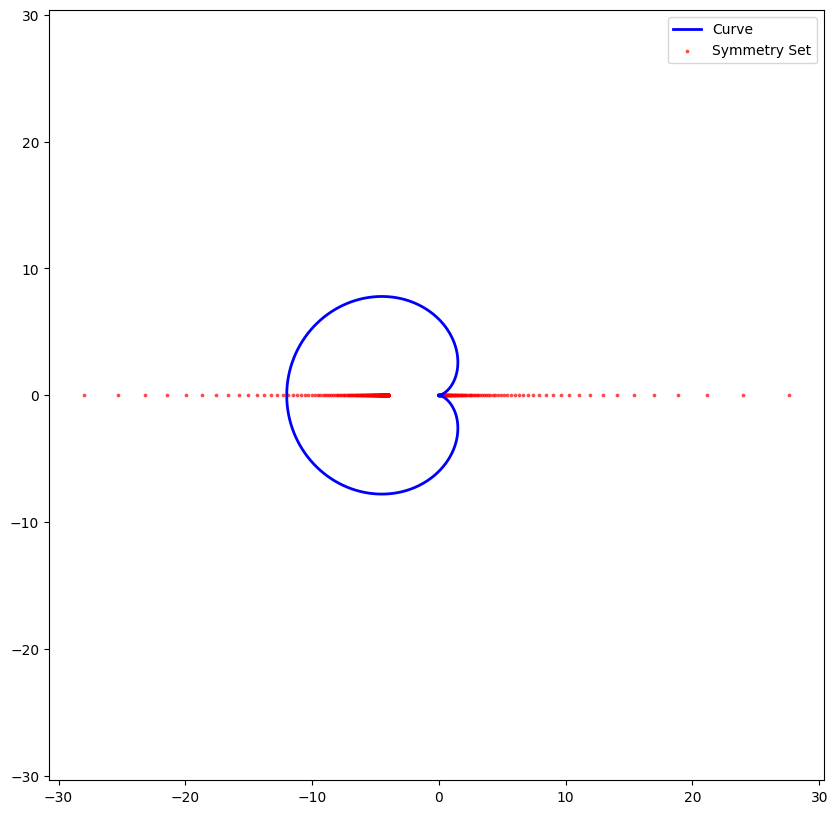

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('symmetry_set.csv')
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']

plt.figure(figsize=(10, 10))
plt.plot(curve['x'], curve['y'], 'b-', linewidth=2, label='Curve')
plt.scatter(symmetry['x'], symmetry['y'], s=3, color='red', alpha=0.6, label='Symmetry Set')
plt.axis('equal')
plt.legend()
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_parametric_curve(x_func, y_func, t_min, t_max, num_points=500, color='b', linewidth=2, label='Parametric Curve'):
    """
    Plots a 2D parametric curve given x(t) and y(t).

    Parameters:
        x_func, y_func : callable
            Functions defining the parametric curve, i.e. x = x(t), y = y(t)
        t_min, t_max : float
            Range of the parameter t
        num_points : int, optional
            Number of sample points (default 500)
        color : str, optional
            Curve color (default 'b')
        linewidth : float, optional
            Width of the curve line (default 2)
        label : str, optional
            Legend label for the curve (default 'Parametric Curve')
    """
    # Generate parameter values
    t_vals = np.linspace(t_min, t_max, num_points)
    
    # Evaluate x(t), y(t)
    x_vals = x_func(t_vals)
    y_vals = y_func(t_vals)

    # Plot
    plt.figure(figsize=(7,7))
    plt.plot(x_vals, y_vals, color=color, linewidth=linewidth, label=label)
    plt.xlabel("x(t)")
    plt.ylabel("y(t)")
    plt.title("2D Parametric Curve")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()


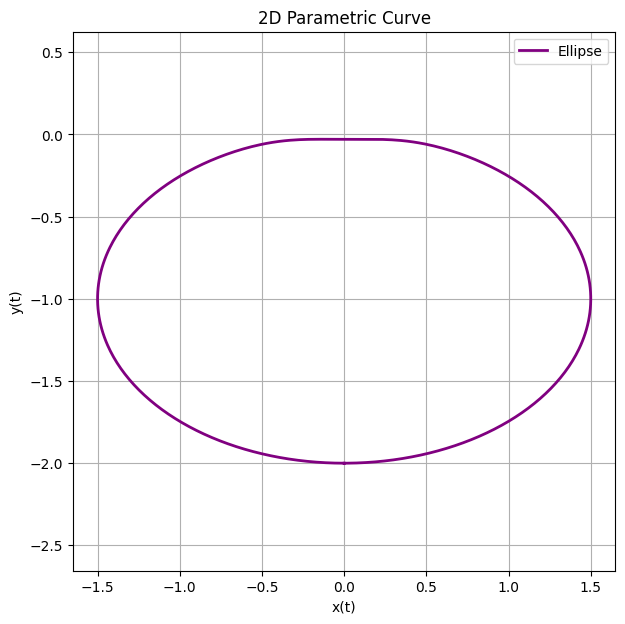

In [46]:
a, b = 1.5,1
H,q = 0.03,20
x_func = lambda t: a * np.sin(t)
y_func = lambda t: (b * (np.cos(t)-1)) - (H * np.exp(-np.longdouble(q)*(np.longdouble(t)**2)))

plot_parametric_curve(x_func, y_func, -np.pi,np.pi, color='purple', label='Ellipse')

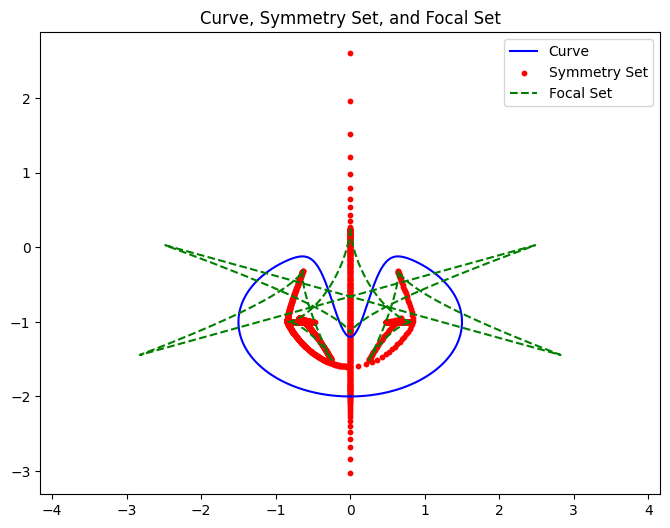

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("symmetry_focal_set.csv")

# Separate points
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']
focal = df[df['type'] == 'focal']

plt.figure(figsize=(8,6))

# Curve as solid blue
plt.plot(curve['x'], curve['y'], 'b-', label='Curve')

# Symmetry points as red dots
plt.scatter(symmetry['x'], symmetry['y'], c='r', s=10, label='Symmetry Set')

# Focal set as dashed green line
plt.plot(focal['x'], focal['y'], 'g--', label='Focal Set')

plt.axis('equal')
plt.legend()
plt.title("Curve, Symmetry Set, and Focal Set")
plt.show()


## Persistence tracking

In [16]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# ============================================================================
# PARAMETERS
# ============================================================================
a = 1.025  # Curve parameter
b = 0.09   # Curve parameter

CURVE_X_RANGE = (-0.1, 1.1)  # Range of x values for curve generation
CURVE_NUM_POINTS = 3000      # Number of points to generate on curve
MAX_RADIUS = 1.0             # Maximum radius for filtration
NUM_RADII = 1000             # Number of radius values in filtration

# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def generate_curve_points(x_range=CURVE_X_RANGE, num_points=CURVE_NUM_POINTS):
    """
    Generate points on the curve y^2 - 2bxy = a^2(x - x^3)
    
    This is solved as a quadratic equation in y for each x:
    y^2 - 2bxy - a^2(x - x^3) = 0
    
    Using quadratic formula:
    y = [2bx ± sqrt(4b^2*x^2 + 4a^2(x - x^3))] / 2
    """
    curve_points = []
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    
    for x in x_vals:
        discriminant = 4*b**2*x**2 + 4*a**2*(x - x**3)
        
        if discriminant >= 0:
            sqrt_disc = np.sqrt(discriminant)
            y1 = (2*b*x + sqrt_disc) / 2
            y2 = (2*b*x - sqrt_disc) / 2
            
            curve_points.append([x, y1])
            if abs(y1 - y2) > 1e-6:  # Add second solution if distinct
                curve_points.append([x, y2])
    
    # Sort by x coordinate to maintain curve ordering
    curve_points = np.array(curve_points)
    sorted_indices = np.argsort(curve_points[:, 0])
    return curve_points[sorted_indices]


def count_connected_components(inside_mask):
    """
    Count connected components from boolean mask of curve points.
    
    Points are connected if they are consecutive along the curve.
    A component is a maximal sequence of consecutive True values.
    """
    if not np.any(inside_mask):
        return 0
    
    num_components = 0
    in_component = False
    
    for is_inside in inside_mask:
        if is_inside and not in_component:
            num_components += 1
            in_component = True
        elif not is_inside:
            in_component = False
    
    return num_components


def compute_persistence_diagram(curve_points, circle_center, 
                               max_radius=MAX_RADIUS, num_radii=NUM_RADII):
    """
    Compute persistence diagram for a single circle center.
    
    Algorithm:
    1. For each radius r from 0 to max_radius:
       - Count connected components of curve inside circle
    2. Track births and deaths of components:
       - When count increases: new components born
       - When count decreases: components die (merge or disappear)
    3. Apply rule: "component born first dies last"
       - Use stack: newest components die first (LIFO)
    
    Returns:
    - persistence_pairs: List of (birth_radius, death_radius) tuples
    - radii: Array of radius values used
    - component_counts: Number of components at each radius
    """
    radii = np.linspace(0, max_radius, num_radii)
    
    # Precompute all distances from circle center
    distances = np.sqrt((curve_points[:, 0] - circle_center[0])**2 + 
                       (curve_points[:, 1] - circle_center[1])**2)
    
    # Count components at each radius
    component_counts = np.array([
        count_connected_components(distances <= r) for r in radii
    ])
    
    # Build persistence pairs using stack for birth times
    birth_stack = []  # Stack: first element is oldest, last is youngest
    persistence_pairs = []
    
    prev_count = 0
    for r, count in zip(radii, component_counts):
        # Birth events: new components appear
        if count > prev_count:
            num_births = count - prev_count
            for _ in range(num_births):
                birth_stack.append(r)
        
        # Death events: components merge or disappear
        elif count < prev_count:
            num_deaths = prev_count - count
            # Kill youngest components (LIFO ensures first born dies last)
            for _ in range(num_deaths):
                if birth_stack:
                    birth_r = birth_stack.pop()
                    persistence_pairs.append((birth_r, r))
        
        prev_count = count
    
    # Remaining components persist until max_radius
    for birth_r in birth_stack:
        persistence_pairs.append((birth_r, max_radius))
    
    return persistence_pairs, radii, component_counts



PERSISTENCE DIAGRAM COMPUTATION FOR POTATO CURVE
Curve: y² - 2bxy = a²(x - x³)  with a = 1.025, b = 0.09

Step 1: Generating curve points...
  ✓ Generated 5018 points on the curve

Step 2: Loading circle centers...
  ✓ Loaded 200 circle centers from potato_circle_points.csv

Step 3: Computing persistence for 200 centers...
  (Filtration: 1000 radius values from 0 to 1.0)
  Processing center 1/200...
  Processing center 50/200...
  Processing center 100/200...
  Processing center 150/200...
  Processing center 200/200...
  ✓ Computed 370546 topological features

Step 4: Creating visualizations...
  ✓ Saved: persistence_diagram.png
  ✓ Saved: persistence_data.csv

SUMMARY STATISTICS
Total topological features (H₀): 370546

Persistence statistics:
  Mean:     0.0802
  Median:   0.0450
  Std Dev:  0.0876
  Min:      0.0010
  Max:      0.6396

Top 5 most persistent features:
  1. Birth=0.3604, Death=1.0000, Persistence=0.6396
  2. Birth=0.3604, Death=1.0000, Persistence=0.6396
  3. Birth=0.

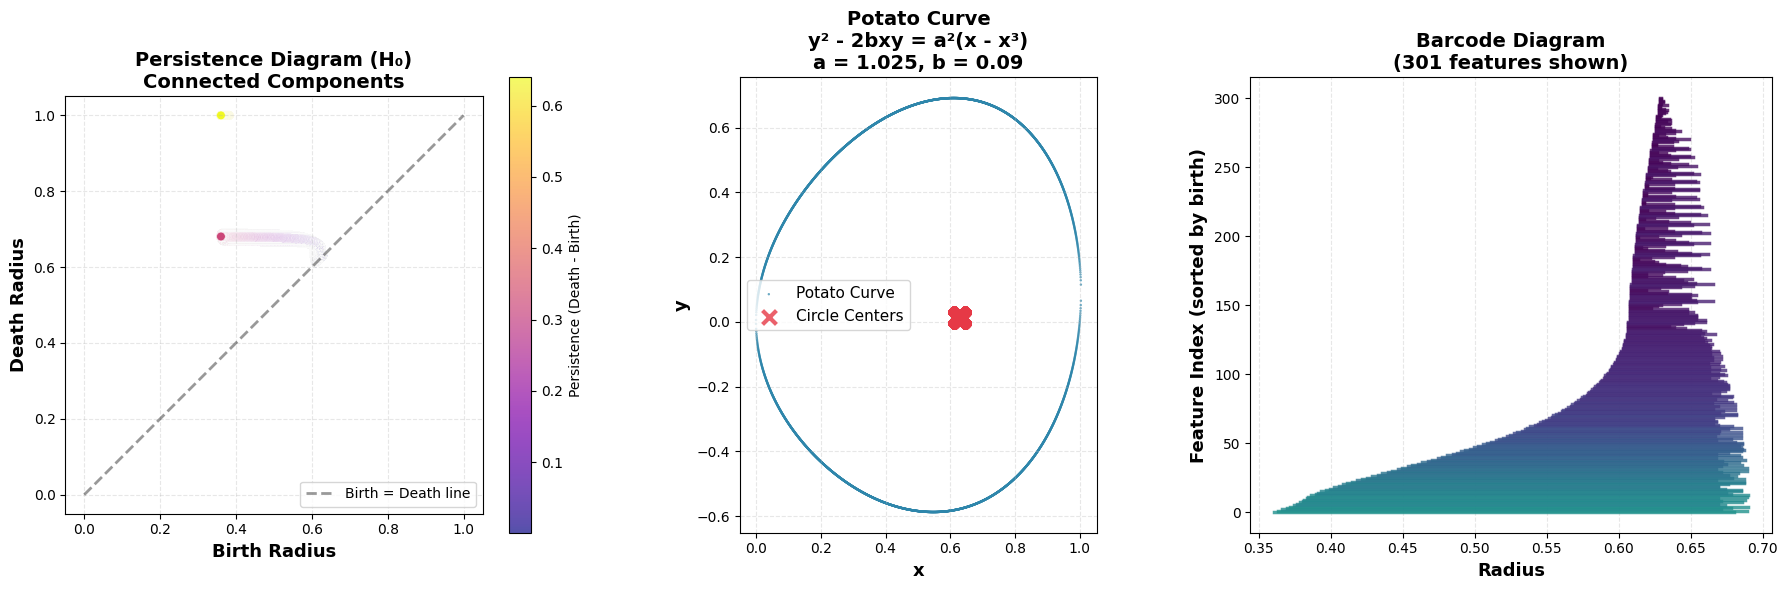

In [17]:
print("="*70)
print("PERSISTENCE DIAGRAM COMPUTATION FOR POTATO CURVE")
print("="*70)
print(f"Curve: y² - 2bxy = a²(x - x³)  with a = {a}, b = {b}")
print()

# Generate curve
print("Step 1: Generating curve points...")
curve_points = generate_curve_points()
print(f"  ✓ Generated {len(curve_points)} points on the curve")

# Load circle centers
print("\nStep 2: Loading circle centers...")
csv_files = ['potato_circle_points.csv']

circle_centers = None
for csv_file in csv_files:
    if os.path.exists(csv_file):
        try:
            df = pd.read_csv(csv_file)
            # Try different column name conventions
            if 'x' in df.columns and 'y' in df.columns:
                circle_centers = df[['x', 'y']].values
            elif 'X' in df.columns and 'Y' in df.columns:
                circle_centers = df[['X', 'Y']].values
            else:
                circle_centers = df.iloc[:, :2].values
            print(f"  ✓ Loaded {len(circle_centers)} circle centers from {csv_file}")
            break
        except Exception as e:
            print(f"  ✗ Error reading {csv_file}: {e}")

# Compute persistence
print(f"\nStep 3: Computing persistence for {len(circle_centers)} centers...")
print(f"  (Filtration: {NUM_RADII} radius values from 0 to {MAX_RADIUS})")

all_persistence_pairs = []
all_metadata = []

for idx, center in enumerate(circle_centers):
    if (idx + 1) % 50 == 0 or idx == 0 or idx == len(circle_centers) - 1:
        print(f"  Processing center {idx+1}/{len(circle_centers)}...")
    
    persistence_pairs, radii, component_counts = compute_persistence_diagram(
        curve_points, center
    )
    
    for birth, death in persistence_pairs:
        all_persistence_pairs.append((birth, death))
        all_metadata.append({
            'center_idx': idx,
            'center_x': center[0],
            'center_y': center[1],
            'birth': birth,
            'death': death,
            'persistence': death - birth
        })

print(f"  ✓ Computed {len(all_persistence_pairs)} topological features")

# Create visualizations
print("\nStep 4: Creating visualizations...")
fig = plt.figure(figsize=(18, 6))

# Plot 1: Persistence Diagram
ax1 = plt.subplot(131)
births = np.array([p[0] for p in all_persistence_pairs])
deaths = np.array([p[1] for p in all_persistence_pairs])
persistences = deaths - births

scatter = ax1.scatter(births, deaths, c=persistences, cmap='plasma', 
                        alpha=0.7, s=40, edgecolors='white', linewidths=0.5)
cbar = plt.colorbar(scatter, ax=ax1, label='Persistence (Death - Birth)')

max_val = max(deaths.max(), births.max())
ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.4, linewidth=2, 
        label='Birth = Death line')

ax1.set_xlabel('Birth Radius', fontsize=13, fontweight='bold')
ax1.set_ylabel('Death Radius', fontsize=13, fontweight='bold')
ax1.set_title('Persistence Diagram (H₀)\nConnected Components', 
                fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.set_aspect('equal', adjustable='box')

# Plot 2: The Curve with Circle Centers
ax2 = plt.subplot(132)
ax2.scatter(curve_points[:, 0], curve_points[:, 1], s=3, alpha=0.7, 
            c='#2E86AB', label='Potato Curve', edgecolors='none')
ax2.scatter(circle_centers[:, 0], circle_centers[:, 1], c='#E63946', 
            s=100, marker='x', linewidths=3, label='Circle Centers', 
            zorder=10, alpha=0.8)

ax2.set_xlabel('x', fontsize=13, fontweight='bold')
ax2.set_ylabel('y', fontsize=13, fontweight='bold')
ax2.set_title(f'Potato Curve\ny² - 2bxy = a²(x - x³)\na = {a}, b = {b}', 
                fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11, loc='best')
ax2.set_aspect('equal', adjustable='box')

# Plot 3: Barcode Diagram
ax3 = plt.subplot(133)
sorted_data = sorted(all_metadata, key=lambda x: x['birth'])

# Sample if too many features
display_data = sorted_data
if len(sorted_data) > 300:
    step = len(sorted_data) // 300
    display_data = sorted_data[::step]

for i, data in enumerate(display_data):
    color = plt.cm.viridis(data['persistence'] / persistences.max())
    ax3.plot([data['birth'], data['death']], [i, i], 
            linewidth=2.5, alpha=0.8, color=color)

ax3.set_xlabel('Radius', fontsize=13, fontweight='bold')
ax3.set_ylabel('Feature Index (sorted by birth)', fontsize=13, fontweight='bold')
ax3.set_title(f'Barcode Diagram\n({len(display_data)} features shown)', 
                fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='x')

plt.tight_layout()
plt.savefig('persistence_diagram.png', dpi=300, 
            bbox_inches='tight', facecolor='white')
print("  ✓ Saved: persistence_diagram.png")

# Save data
metadata_df = pd.DataFrame(all_metadata)
metadata_df.to_csv('persistence_data.csv', index=False)
print("  ✓ Saved: persistence_data.csv")

# Print summary
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Total topological features (H₀): {len(all_persistence_pairs)}")
print(f"\nPersistence statistics:")
print(f"  Mean:     {persistences.mean():.4f}")
print(f"  Median:   {np.median(persistences):.4f}")
print(f"  Std Dev:  {persistences.std():.4f}")
print(f"  Min:      {persistences.min():.4f}")
print(f"  Max:      {persistences.max():.4f}")

print(f"\nTop 5 most persistent features:")
top_indices = np.argsort(persistences)[-5:][::-1]
for rank, idx in enumerate(top_indices, 1):
    birth, death = all_persistence_pairs[idx]
    pers = death - birth
    print(f"  {rank}. Birth={birth:.4f}, Death={death:.4f}, Persistence={pers:.4f}")

print("="*70)
print("\nDONE! Check the output files in outputs/")
print("="*70)

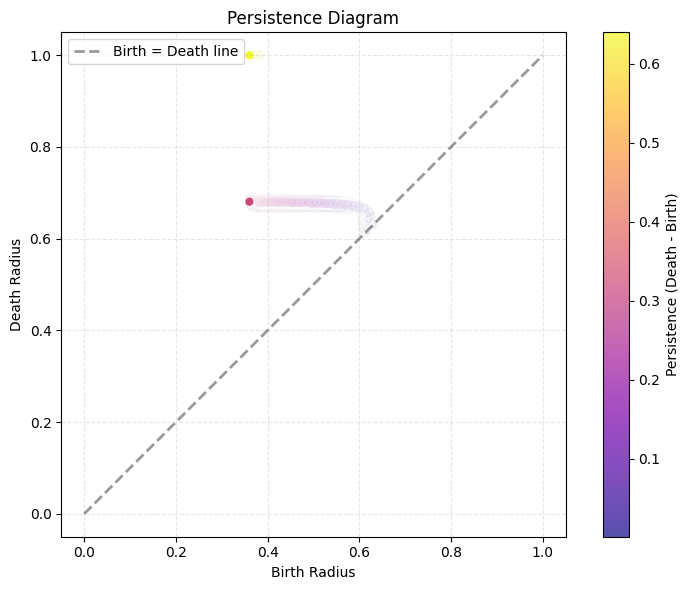

In [18]:
births = np.array([p[0] for p in all_persistence_pairs])
deaths = np.array([p[1] for p in all_persistence_pairs])
persistences = deaths - births

fig, ax = plt.subplots(figsize=(8, 6))  # Standalone plot (adjust size as needed)
scatter = ax.scatter(
    births, deaths, 
    c=persistences, cmap='plasma', alpha=0.7, 
    s=40, edgecolors='white', linewidths=0.5
)
cbar = plt.colorbar(scatter, ax=ax, label='Persistence (Death - Birth)')

max_val = max(deaths.max(), births.max())
ax.plot(
    [0, max_val], [0, max_val], 'k--', 
    alpha=0.4, linewidth=2, label='Birth = Death line'
)

ax.set_xlabel('Birth Radius')
ax.set_ylabel('Death Radius')
ax.set_title('Persistence Diagram')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()